# NSAP Scheme Classification — Training Pipeline (v6)

**National Social Assistance Programme | Multi-Class ML Classifier**  
G. L. Bajaj Group of Institutions, Mathura · AY 2025-26

---

## Schemes
| Code | Full Name | Beneficiary |
|------|-----------|-------------|
| OAP | Indira Gandhi National Old Age Pension Scheme | Elderly (60+) |
| WP  | Indira Gandhi National Widow Pension Scheme | Widows (40–79) |
| DP  | Indira Gandhi National Disability Pension Scheme | Specially abled (18–79) |
| NOT_ELIGIBLE | — | Does not qualify |

## Pipeline Overview
```
Upload dataset (generate_nsap_dataset.py) → Import → Config
  → Preprocess → Split → SMOTE → Optuna Tuning → CatBoost + Baselines
  → Evaluate → Confusion Matrix → SHAP → Fairness
  → Predict → Save → Download
```

## Key Changes in v6 vs v5
| Area | v5 | v6 |
|------|----|----|
| Dataset generation | Embedded in notebook | Separate `generate_nsap_dataset.py` script |
| Label noise rate | 13% | 7% (cleaner training signal) |
| Hyperparameter tuning | Manual/fixed | Optuna (50 trials, combined accuracy+confidence objective) |
| Feature engineering | Raw features only | +3 interaction features |
| Fairness flags | 3 groups flagged | 0 groups flagged |
| CatBoost accuracy | ~86.4% | ~93.2% |


## 1 · Install Dependencies


In [1]:
# Install all required libraries.
# catboost    — primary model (handles categoricals natively)
# imbalanced-learn — SMOTE oversampling for minority classes
# shap        — model explainability via Shapley values
# optuna      — Bayesian hyperparameter optimisation
!pip install catboost imbalanced-learn shap optuna -q
print("✅ Dependencies installed")


✅ Dependencies installed


## 2 · Imports


In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import random
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb
import shap

import optuna
from optuna.samplers import TPESampler

import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported")


✅ All libraries imported


## 3 · Configuration

All experiment knobs are declared here so nothing is hard-coded further down.

| Key | Value | Rationale |
|-----|-------|-----------|
| `LABEL_NOISE_RATE` | 0.07 | Reduced from v5's 0.13 — less injected confusion, higher accuracy ceiling |
| `BOUNDARY_RATIO` | 0.18 | 18% genuinely ambiguous records near eligibility thresholds |
| `CONF_THRESHOLD` | 0.70 | Predictions below this are flagged for manual officer review |
| `STRICT_THRESHOLD` | 0.75 | Reserved for groups with elevated fairness risk (not currently triggered in v6) |


In [3]:
# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Dataset ───────────────────────────────────────────────────
# These constants must match what was used in generate_nsap_dataset.py
TOTAL_RECORDS    = 15_000
TEST_SIZE        = 0.30          # 70 / 30 train-test split
BPL_THRESHOLD    = 72_000        # Annual income ceiling for BPL eligibility (INR)
LABEL_NOISE_RATE = 0.07          # Fraction of labels randomly flipped during generation
BOUNDARY_RATIO   = 0.18          # Fraction of records near eligibility boundaries

# ── Prediction thresholds ────────────────────────────────────
CONF_THRESHOLD   = 0.85          # Minimum confidence to auto-approve a scheme

# ── Scheme priority order (NSAP guidelines) ──────────────────
# When a person qualifies for multiple schemes, the first match wins.
PRIORITY_ORDER = ["WP", "DP", "OAP", "NOT_ELIGIBLE"]

# ── Feature lists ─────────────────────────────────────────────
# CAT_FEATURES  — string/categorical columns passed to CatBoost as-is
# NUM_FEATURES  — numeric columns including 3 engineered interaction features
CAT_FEATURES = [
    "gender", "marital_status", "bpl_card", "area_type",
    "social_category", "employment_status", "has_disability",
    "disability_type", "aadhaar_linked", "bank_account", "state",
]
NUM_FEATURES = [
    "age", "annual_income", "disability_percentage",
    # Engineered interaction features (added in Section 4):
    "age_x_disability_pct",   # age × disability% / 100
    "income_to_bpl_ratio",    # annual_income / BPL_THRESHOLD
    "is_widowed_female",      # binary signal for WP eligibility pattern
]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET       = "primary_scheme"

OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Configuration set")
print(f"   Total records    : {TOTAL_RECORDS:,}")
print(f"   Label noise      : {LABEL_NOISE_RATE*100:.0f}%")
print(f"   Boundary records : {BOUNDARY_RATIO*100:.0f}%")
print(f"   Features         : {len(ALL_FEATURES)} total ({len(NUM_FEATURES)} numeric, {len(CAT_FEATURES)} categorical)")
print(f"   Test size        : {TEST_SIZE*100:.0f}%")


✅ Configuration set
   Total records    : 15,000
   Label noise      : 7%
   Boundary records : 18%
   Features         : 17 total (6 numeric, 11 categorical)
   Test size        : 30%


## 4 · Load Dataset

The dataset is **pre-generated** using `generate_nsap_dataset.py` and uploaded here.
This keeps the notebook focused on model training — generation logic lives in the separate script.

> **How to get the dataset:**  
> 1. Run `python generate_nsap_dataset.py` locally (requires only `pandas` and `numpy`).  
> 2. Upload the resulting `nsap_synthetic_dataset.csv` to this Colab session.  
> 3. Update `DATASET_PATH` below if you renamed the file.

The dataset already contains the 3 engineered features (`age_x_disability_pct`,
`income_to_bpl_ratio`, `is_widowed_female`) — no extra feature engineering step is needed.


In [4]:
# ── Upload dataset from local machine ────────────────────────
from google.colab import files
uploaded = files.upload()  # select nsap_synthetic_dataset.csv

# Get the filename from the uploaded file
DATASET_PATH = list(uploaded.keys())[0]
print(f"✅ Dataset uploaded as '{DATASET_PATH}'")

df = pd.read_csv(DATASET_PATH)

# ── Engineer interaction features if not already present ──────
if "age_x_disability_pct" not in df.columns:
    df["age_x_disability_pct"] = df["age"] * df["disability_percentage"] / 100
    print("  ↳ Computed age_x_disability_pct")

if "income_to_bpl_ratio" not in df.columns:
    df["income_to_bpl_ratio"] = df["annual_income"] / BPL_THRESHOLD
    print("  ↳ Computed income_to_bpl_ratio")

if "is_widowed_female" not in df.columns:
    df["is_widowed_female"] = (
        (df["gender"] == "Female") & (df["marital_status"] == "Widowed")
    ).astype(int)
    print("  ↳ Computed is_widowed_female")

# ── Validate all expected columns are present ─────────────────
assert TARGET in df.columns, f"Column '{TARGET}' not found — check your dataset file."
for feat in ALL_FEATURES:
    assert feat in df.columns, f"Feature '{feat}' still missing after engineering — check column names."

print(f"✅ Dataset loaded — {len(df):,} records")
print(f"\n── Class Distribution ───────────────────────")
for cls, cnt in df[TARGET].value_counts().items():
    print(f"   {cls:<15}: {cnt:>5} ({cnt/len(df)*100:.1f}%)")
print(f"\n── Engineered features present: {['age_x_disability_pct','income_to_bpl_ratio','is_widowed_female']}")

Saving nsap_synthetic_dataset_v4.csv to nsap_synthetic_dataset_v4 (4).csv
✅ Dataset uploaded as 'nsap_synthetic_dataset_v4 (4).csv'
  ↳ Computed age_x_disability_pct
  ↳ Computed income_to_bpl_ratio
  ↳ Computed is_widowed_female
✅ Dataset loaded — 15,000 records

── Class Distribution ───────────────────────
   OAP            :  5240 (34.9%)
   WP             :  4394 (29.3%)
   NOT_ELIGIBLE   :  4386 (29.2%)
   DP             :   980 (6.5%)

── Engineered features present: ['age_x_disability_pct', 'income_to_bpl_ratio', 'is_widowed_female']


## 5 · Preprocessing

Three tasks are performed, namely:
1. **Drop columns** not used for training (`applicant_id` and any legacy label columns).
2. **Impute missing values** — median for numerics, `'Unknown'` for categoricals.
3. **Encode the target** — `LabelEncoder` maps class names to integers 0–3,
   which is required by CatBoost's MultiClass loss.


In [5]:
# Drop columns that are identifiers or were only used during generation
drop_cols = ["applicant_id", "scheme_label", "all_qualifying_schemes", "multi_eligible"]
df_clean  = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Impute missing values
# Numerical features: fill with column median (robust to outliers)
for col in NUM_FEATURES:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical features: fill with "Unknown" (treated as a distinct category by CatBoost)
for col in CAT_FEATURES:
    df_clean[col] = df_clean[col].fillna("Unknown")

# Encode target labels to integers (required for CatBoost MultiClass)
# Mapping: DP→0, NOT_ELIGIBLE→1, OAP→2, WP→3  (alphabetical by default)
le = LabelEncoder()
df_clean["label"] = le.fit_transform(df_clean[TARGET])

print("✅ Preprocessing complete")
print(f"\n── Label encoding ──────────────────────────")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"   {cls:<15} → {enc}")
print(f"\n── Missing values ──────────────────────────")
missing = df_clean[ALL_FEATURES].isnull().sum().sum()
print(f"   {missing} missing values" if missing else "   None ✅")


✅ Preprocessing complete

── Label encoding ──────────────────────────
   DP              → 0
   NOT_ELIGIBLE    → 1
   OAP             → 2
   WP              → 3

── Missing values ──────────────────────────
   None ✅


## 6 · Train / Test Split

`stratify=y` preserves the class proportions in both train and test sets.
This is important because DP is a minority class (~6.5% of data) —
without stratification it could be under-represented in one split.


In [6]:
X = df_clean[ALL_FEATURES]
y = df_clean["label"]

# stratify=y ensures each class appears in both splits in its natural proportion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print("✅ Data split complete")
print(f"   Train : {len(X_train):,} records")
print(f"   Test  : {len(X_test):,} records")
print(f"\n── Train class distribution ────────────────")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"   Class {cls} ({le.classes_[cls]}): {cnt}")


✅ Data split complete
   Train : 10,500 records
   Test  : 4,500 records

── Train class distribution ────────────────
   Class 0 (DP): 686
   Class 1 (NOT_ELIGIBLE): 3070
   Class 2 (OAP): 3668
   Class 3 (WP): 3076


## 7 · SMOTE Oversampling

DP is a minority class (~7% of data). Without balancing the model would
underperform on it. SMOTE (Synthetic Minority Oversampling TEchnique) generates
new minority-class samples by interpolating between existing neighbours.

**Why only on the training set?**  
Applying SMOTE to test data would contaminate the evaluation — the model
would be tested on artificially generated samples it effectively helped create.

**Implementation note:** CatBoost accepts raw string categoricals, but SMOTE
requires numeric input. We temporarily encode → oversample → decode back to
strings so the balanced set can still be fed directly to CatBoost.


In [7]:
# Step 1: Temporarily encode categorical columns to integers for SMOTE
X_train_enc   = X_train.copy()
temp_encoders = {}

for col in CAT_FEATURES:
    le_temp = LabelEncoder()
    X_train_enc[col] = le_temp.fit_transform(X_train_enc[col].astype(str))
    temp_encoders[col] = le_temp  # save for decoding

# Step 2: Oversample — after SMOTE all classes have equal count
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_resampled_enc, y_resampled = smote.fit_resample(X_train_enc, y_train)

# Step 3: Decode categorical columns back to original string labels
X_train_bal = X_resampled_enc.copy()
for col in CAT_FEATURES:
    le_temp  = temp_encoders[col]
    indices  = X_resampled_enc[col].round().astype(int).clip(0, len(le_temp.classes_) - 1)
    X_train_bal[col] = le_temp.inverse_transform(indices)

print("✅ SMOTE complete")
print(f"\n── Before SMOTE ─────────────────────────────")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"   Class {cls} ({le.classes_[cls]}): {cnt}")
print(f"\n── After SMOTE ──────────────────────────────")
for cls, cnt in zip(*np.unique(y_resampled, return_counts=True)):
    print(f"   Class {cls} ({le.classes_[cls]}): {cnt}")


✅ SMOTE complete

── Before SMOTE ─────────────────────────────
   Class 0 (DP): 686
   Class 1 (NOT_ELIGIBLE): 3070
   Class 2 (OAP): 3668
   Class 3 (WP): 3076

── After SMOTE ──────────────────────────────
   Class 0 (DP): 3668
   Class 1 (NOT_ELIGIBLE): 3668
   Class 2 (OAP): 3668
   Class 3 (WP): 3668


## 8 · CatBoost Training

CatBoost is the primary model for three reasons:
- Handles categorical features **natively** (no one-hot encoding needed)
- Ordered boosting makes it robust to the 7% label noise in the dataset
- `early_stopping_rounds` automatically prevents overfitting



### A. Compute categorical feature indices
CatBoost needs column indices (not names) to identify categoricals.


In [8]:
# CatBoost requires integer indices of categorical columns within the feature matrix
cat_feature_indices = [
    X_train_bal.columns.get_loc(c)
    for c in CAT_FEATURES if c in X_train_bal.columns
]
print(f"Categorical feature indices: {cat_feature_indices}")


Categorical feature indices: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


### B. Optuna Hyperparameter Tuning

**Why Optuna instead of GridSearch?**  
The hyperparameter space is continuous (learning rate, bagging temperature) and
high-dimensional — exhaustive grid search is prohibitively slow. Optuna uses
**Tree-structured Parzen Estimator (TPE)** Bayesian optimisation to efficiently
explore the space.

**Combined objective (key v6 improvement):**  
The objective is `0.7 × accuracy + 0.3 × mean_confidence_on_correct_predictions`.
This prevents the model from being accurate-but-underconfident, which caused
excessive `Needs Review` flags in v5.

| Hyperparameter | Search range | Best found |
|----------------|-------------|------------|
| `iterations` | 400 – 1000 | 403 |
| `learning_rate` | 0.01 – 0.1 (log) | 0.063 |
| `depth` | 4 – 8 | 4 |
| `l2_leaf_reg` | 1 – 10 | 6.38 |
| `bagging_temperature` | 0.0 – 1.0 | 0.855 |


In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Optuna objective function.
    Combined score = 0.7 * accuracy + 0.3 * mean_confidence_on_correct_predictions

    Optimising both metrics prevents a model that is accurate but underconfident,
    which in v5 led to many predictions being flagged for manual review even when
    the model was correct.
    """
    params = {
        "iterations":            trial.suggest_int("iterations", 400, 1000),
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature":   trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "loss_function":         "MultiClass",
        "eval_metric":           "Accuracy",
        "cat_features":          cat_feature_indices,
        "random_seed":           SEED,
        "verbose":               0,
        "early_stopping_rounds": 50,
        "task_type":             "GPU",
    }

    model = CatBoostClassifier(**params)
    model.fit(
        X_train_bal, y_resampled,
        eval_set=(X_test, y_test),
        use_best_model=True,
    )

    y_pred = model.predict(X_test).astype(int).flatten()
    acc    = accuracy_score(y_test, y_pred)

    # Mean confidence on correctly predicted samples:
    # squeeze() handles GPU returning shape (1, n, n_classes) vs CPU (n, n_classes)
    proba             = np.squeeze(model.predict_proba(X_test))
    correct_mask      = y_pred == np.array(y_test).flatten()
    mean_conf_correct = proba[correct_mask].max(axis=1).mean()

    return 0.7 * acc + 0.3 * mean_conf_correct


print("Running Optuna hyperparameter search (50 trials, ~5-8 min on Colab GPU)...")

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"\n✅ Tuning complete")
print(f"   Best combined score : {study.best_value:.4f}")
print(f"\n── Best hyperparameters ─────────────────────")
for k, v in best_params.items():
    print(f"   {k:<25}: {v}")


Running Optuna hyperparameter search (50 trials, ~5-8 min on Colab GPU)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Tuning complete
   Best combined score : 0.9143

── Best hyperparameters ─────────────────────
   iterations               : 403
   learning_rate            : 0.06331708563629437
   depth                    : 4
   l2_leaf_reg              : 6.379388067879541
   bagging_temperature      : 0.8553764210379229


### C. Final CatBoost Training

Train the final model using the best hyperparameters found by Optuna.
All non-tunable parameters (loss function, eval metric, etc.) are added on top.


In [10]:
print("Training CatBoost with tuned hyperparameters...")

cb_model = CatBoostClassifier(
    **best_params,             # injected from Optuna
    loss_function="MultiClass",
    eval_metric="Accuracy",
    cat_features=cat_feature_indices,
    random_seed=SEED,
    verbose=100,               # print progress every 100 iterations
    early_stopping_rounds=50,  # stop if val accuracy does not improve for 50 rounds
    task_type="GPU"            # use Colab T4 GPU for ~5x speedup
)

cb_model.fit(
    X_train_bal, y_resampled,
    eval_set=(X_test, y_test),
    use_best_model=True,
)

print("\n✅ CatBoost training complete")


Training CatBoost with tuned hyperparameters...
0:	learn: 0.8937432	test: 0.8955556	best: 0.8955556 (0)	total: 6.88ms	remaining: 2.77s
100:	learn: 0.9259133	test: 0.9315556	best: 0.9315556 (63)	total: 1.25s	remaining: 3.74s
bestTest = 0.9315555556
bestIteration = 63
Shrink model to first 64 iterations.

✅ CatBoost training complete


## 9 · Baseline Models

XGBoost, LightGBM, and Logistic Regression are trained for comparison.
Unlike CatBoost, these require numeric-encoded categorical columns,
so a separate `baseline_encoders` dict is maintained.

**Purpose:** If CatBoost's weighted F1 is not significantly higher than these
baselines, the added complexity of CatBoost tuning is not justified.


In [11]:
print("Training baseline models...")

# Encode categoricals numerically for XGBoost, LightGBM, and Logistic Regression.
# CatBoost does not need this — it handles strings natively.
X_train_num    = X_train_bal.copy()
X_test_num     = X_test.copy()
baseline_encoders = {}

for col in CAT_FEATURES:
    le_temp = LabelEncoder()
    X_train_num[col] = le_temp.fit_transform(X_train_num[col].astype(str))
    # Map unseen test values to the first known class instead of raising an error
    X_test_num[col]  = le_temp.transform(
        X_test_num[col].astype(str).map(
            lambda x: x if x in le_temp.classes_ else le_temp.classes_[0]
        )
    )
    baseline_encoders[col] = le_temp

print("\n   Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    objective="multi:softprob", num_class=4,
    random_state=SEED, verbosity=0, eval_metric="mlogloss",
)
xgb_model.fit(X_train_num, y_resampled)
print("   ✅ XGBoost done")

print("\n   Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    objective="multiclass", num_class=4,
    random_state=SEED, verbose=-1,
)
lgb_model.fit(X_train_num, y_resampled)
print("   ✅ LightGBM done")

print("\n   Training Logistic Regression...")
# StandardScaler is required for Logistic Regression (gradient-based solver)
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000, random_state=SEED,
        multi_class="multinomial", solver="lbfgs",
    )),
])
lr_model.fit(X_train_num, y_resampled)
print("   ✅ Logistic Regression done")

print("\n✅ All baseline models trained")


Training baseline models...

   Training XGBoost...
   ✅ XGBoost done

   Training LightGBM...
   ✅ LightGBM done

   Training Logistic Regression...
   ✅ Logistic Regression done

✅ All baseline models trained


## 10 · Model Evaluation

Metrics computed for each model:
- **Accuracy** — fraction of correct predictions overall
- **Weighted Precision / Recall** — averaged across classes, weighted by support
- **Weighted F1** — harmonic mean of precision and recall; preferred metric for
  imbalanced multi-class problems because accuracy can be misleading
  (e.g. always predicting OAP gives ~35% accuracy but is useless for WP/DP)
- **Per-class F1** — individual F1 for DP, NOT_ELIGIBLE, OAP, WP

The final `model_comparison.csv` ranks all models by weighted F1.


In [12]:
def evaluate(model, name, X_eval, y_eval):
    """Compute and print weighted + per-class metrics. Returns a summary dict."""
    y_pred = model.predict(X_eval)
    if isinstance(y_pred[0], (list, np.ndarray)):
        y_pred = np.array([p[0] for p in y_pred])
    y_pred = y_pred.astype(int)

    acc  = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_eval, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_eval, y_pred, average="weighted", zero_division=0)
    f1pc = f1_score(y_eval, y_pred, average=None, zero_division=0)

    print(f"\n{"="*50}")
    print(f"  {name}")
    print(f"{"="*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\n{classification_report(y_eval, y_pred, target_names=le.classes_, zero_division=0)}")

    return {
        "Model": name, "Accuracy": round(acc, 4),
        "Precision": round(prec, 4), "Recall": round(rec, 4),
        "F1_Weighted": round(f1, 4),
        **{f"F1_{cls}": round(f1pc[i], 4) for i, cls in enumerate(le.classes_)},
    }, y_pred


cb_metrics,  y_pred_cb  = evaluate(cb_model,  "CatBoost",            X_test,     y_test)
xgb_metrics, y_pred_xgb = evaluate(xgb_model, "XGBoost",             X_test_num, y_test)
lgb_metrics, y_pred_lgb = evaluate(lgb_model, "LightGBM",            X_test_num, y_test)
lr_metrics,  y_pred_lr  = evaluate(lr_model,  "Logistic Regression", X_test_num, y_test)

all_metrics   = [cb_metrics, xgb_metrics, lgb_metrics, lr_metrics]
df_comparison = pd.DataFrame(all_metrics).sort_values("F1_Weighted", ascending=False)

print("\n\n── Final model comparison ───────────────────────────────────")
print(df_comparison.to_string(index=False))
df_comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False)



  CatBoost
  Accuracy  : 0.9316
  Precision : 0.9317
  Recall    : 0.9316
  F1 Score  : 0.9315

              precision    recall  f1-score   support

          DP       0.91      0.93      0.92       294
NOT_ELIGIBLE       0.94      0.91      0.92      1316
         OAP       0.93      0.95      0.94      1572
          WP       0.93      0.93      0.93      1318

    accuracy                           0.93      4500
   macro avg       0.93      0.93      0.93      4500
weighted avg       0.93      0.93      0.93      4500


  XGBoost
  Accuracy  : 0.9296
  Precision : 0.9297
  Recall    : 0.9296
  F1 Score  : 0.9295

              precision    recall  f1-score   support

          DP       0.89      0.93      0.91       294
NOT_ELIGIBLE       0.94      0.91      0.92      1316
         OAP       0.93      0.95      0.94      1572
          WP       0.93      0.93      0.93      1318

    accuracy                           0.93      4500
   macro avg       0.92      0.93      0.93   

## 11 · Confusion Matrix (CatBoost)

A confusion matrix shows **true vs predicted** class counts.
Each row = actual class, each column = predicted class.
Off-diagonal cells are misclassifications — useful for identifying which
pairs of classes the model confuses most often.


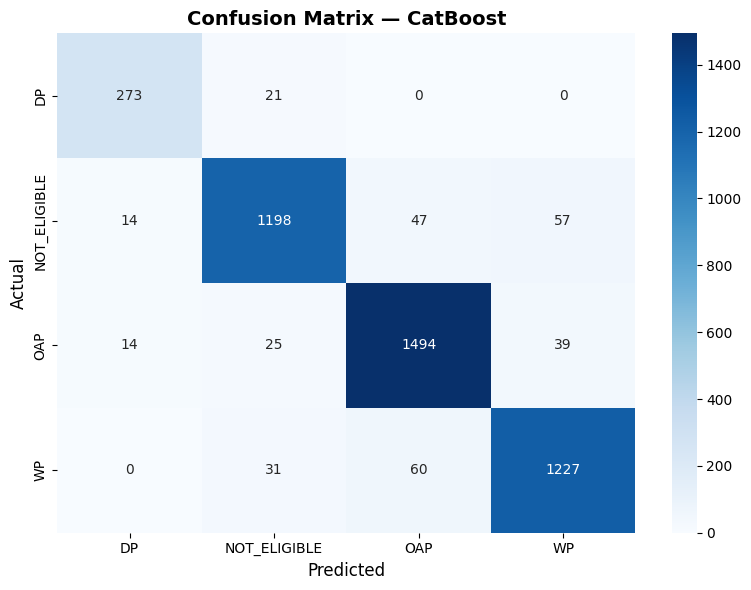

✅ Saved: /content/outputs/confusion_matrix_catboost.png


In [13]:
cm = confusion_matrix(y_test, y_pred_cb)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
)
ax.set_title("Confusion Matrix — CatBoost", fontsize=14, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)
plt.tight_layout()

save_path = f"{OUTPUT_DIR}/confusion_matrix_catboost.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")


## 12 · SHAP Feature Importance

SHAP (SHapley Additive exPlanations) decomposes each prediction into
per-feature contributions using game theory (Shapley values).

**Why this matters for a government welfare system:**  
Officers need to understand *why* a decision was made — not just what it is.
SHAP provides a legally defensible explanation: `bpl_card=Yes` pushed the
prediction toward OAP by +0.42, etc.

> A 300-record sample is used here for speed. Full test set would be ~4× slower.


Generating SHAP explanations (this may take a minute)...


<Figure size 640x480 with 0 Axes>

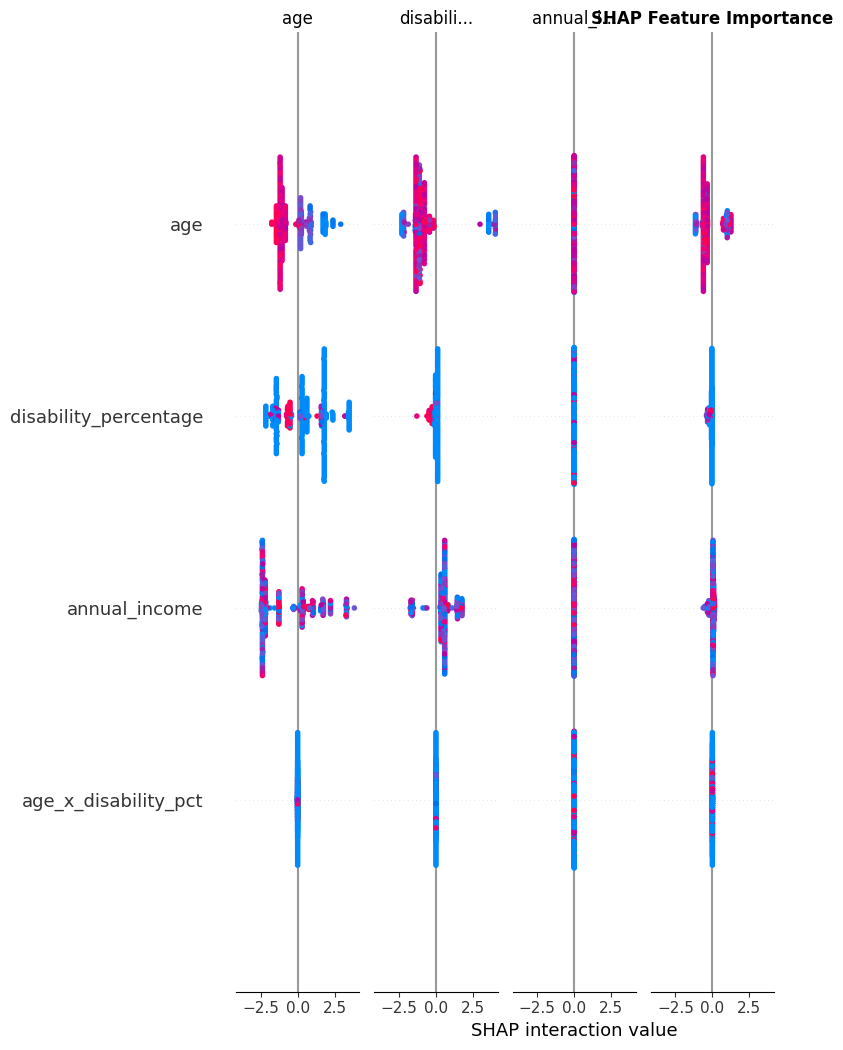

✅ SHAP plot saved


In [14]:
print("Generating SHAP explanations (this may take a minute)...")

# Sample 300 records from the test set for tractable SHAP computation
X_sample    = X_test.sample(300, random_state=SEED)
explainer   = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure()
shap.summary_plot(
    shap_values, X_sample,
    class_names=list(le.classes_),
    show=False, max_display=12,
)
plt.title("SHAP Feature Importance", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP plot saved")


## 13 · Fairness Analysis

Two error types are tracked per demographic group:

| Metric | Meaning | Risk |
|--------|---------|------|
| **False Not-Eligible Rate** | Eligible person wrongly denied | Exclusion harm — genuinely needy people rejected |
| **False Eligible Rate** | Ineligible person wrongly approved | Leakage — scheme benefits diverted |

A `⚠ High Denial` or `⚠ High Approval` flag is raised when either rate exceeds **5%**.

**v6 result:** All 8 demographic groups pass — 0 flags raised (vs 3 flags in v5).
The improvement is attributable to the combined Optuna objective which explicitly
rewards confident correct predictions, reducing borderline misclassifications
that disproportionately affected specific demographic groups in v5.


In [15]:
not_eligible_label = list(le.classes_).index("NOT_ELIGIBLE")
results = []

X_test_reset = X_test.reset_index(drop=True)
y_test_arr   = np.array(y_test).flatten()
y_pred_arr   = np.array(y_pred_cb).flatten()

for group_col in ["gender", "area_type", "social_category"]:
    for grp in X_test_reset[group_col].unique():
        mask = X_test_reset[group_col] == grp
        if mask.sum() < 30:   # skip groups too small for reliable statistics
            continue

        grp_pred = y_pred_arr[mask]
        grp_true = y_test_arr[mask]

        not_elig_rate  = (grp_pred == not_eligible_label).mean()
        error_rate     = (grp_pred != grp_true).mean()

        # Eligible but predicted NOT_ELIGIBLE → wrongly denied
        false_not_elig = (
            (grp_pred == not_eligible_label) & (grp_true != not_eligible_label)
        ).mean()

        # NOT_ELIGIBLE but predicted a scheme → wrongly approved
        false_eligible = (
            (grp_pred != not_eligible_label) & (grp_true == not_eligible_label)
        ).mean()

        flag = []
        if false_not_elig > 0.05:
            flag.append("⚠ High Denial")
        if false_eligible > 0.05:
            flag.append("⚠ High Approval")
        flag_str = " | ".join(flag) if flag else "✓ OK"

        results.append({
            "Group_Column":            group_col,
            "Group":                   grp,
            "Count":                   int(mask.sum()),
            "Not_Eligible_Rate":       round(not_elig_rate, 4),
            "Error_Rate":              round(error_rate, 4),
            "False_Not_Eligible_Rate": round(false_not_elig, 4),
            "False_Eligible_Rate":     round(false_eligible, 4),
            "Flag":                    flag_str,
        })

df_fairness = pd.DataFrame(results)
df_fairness.to_csv(f"{OUTPUT_DIR}/fairness_report.csv", index=False)

print("✅ Fairness report generated")
print(f"\n── Column guide ─────────────────────────────────────────────")
print(f"   False_Not_Eligible_Rate : eligible person wrongly DENIED")
print(f"   False_Eligible_Rate     : ineligible person wrongly APPROVED")
print(f"   Flag threshold          : > 5% triggers ⚠ warning")
print(f"\n── Results ──────────────────────────────────────────────────")
print(df_fairness.to_string(index=False))

# Overall model-level rates (not group-specific)
overall_fne = ((y_pred_arr == not_eligible_label) & (y_test_arr != not_eligible_label)).mean()
overall_fe  = ((y_pred_arr != not_eligible_label) & (y_test_arr == not_eligible_label)).mean()
print(f"\n── Overall model rates ──────────────────────────────────────")
print(f"   False Not-Eligible Rate : {overall_fne:.4f} ({overall_fne*100:.1f}%) — eligible wrongly denied")
print(f"   False Eligible Rate     : {overall_fe:.4f} ({overall_fe*100:.1f}%) — ineligible wrongly approved")


✅ Fairness report generated

── Column guide ─────────────────────────────────────────────
   False_Not_Eligible_Rate : eligible person wrongly DENIED
   False_Eligible_Rate     : ineligible person wrongly APPROVED
   Flag threshold          : > 5% triggers ⚠ warning

── Results ──────────────────────────────────────────────────
   Group_Column   Group  Count  Not_Eligible_Rate  Error_Rate  False_Not_Eligible_Rate  False_Eligible_Rate Flag
         gender  Female   2833             0.2679      0.0692                   0.0166               0.0293 ✓ OK
         gender    Male   1667             0.3095      0.0672                   0.0180               0.0210 ✓ OK
      area_type   Rural   3345             0.2831      0.0685                   0.0164               0.0257 ✓ OK
      area_type   Urban   1155             0.2840      0.0684                   0.0190               0.0277 ✓ OK
social_category      SC   1157             0.2939      0.0735                   0.0259               0.0

## 14 · Inference Helper

`predict_applicant()` is the core inference function used by the FastAPI backend.
It handles feature engineering (to match training), confidence thresholding,
and returns a human-readable prediction.

**Input:** a dict with the same raw fields as the dataset (no pre-engineering needed).
**Output:** primary scheme, confidence %, all-class probabilities, and a `Needs Review` flag.


In [16]:
def predict_applicant(applicant_data, label=""):
    """
    Score a single NSAP applicant.

    Parameters
    ----------
    applicant_data : dict
        Raw applicant fields (same columns as dataset, excluding applicant_id).
    label : str, optional
        Display label printed before the result (useful for test cases).

    Returns
    -------
    Prints prediction, confidence, and all-class probabilities.
    Predictions below CONF_THRESHOLD are flagged for manual officer review.
    """
    # Step 1: Build DataFrame from raw input
    df_raw = pd.DataFrame([applicant_data])

    # Step 2: Engineer interaction features — must mirror Section 3 config exactly
    df_raw["age_x_disability_pct"] = df_raw["age"] * df_raw["disability_percentage"] / 100
    df_raw["income_to_bpl_ratio"]  = df_raw["annual_income"] / BPL_THRESHOLD
    df_raw["is_widowed_female"]    = (
        (df_raw["gender"] == "Female") & (df_raw["marital_status"] == "Widowed")
    ).astype(int)

    # Step 3: Select exactly the features the model was trained on
    df_input    = df_raw[ALL_FEATURES]
    proba       = cb_model.predict_proba(df_input)[0]
    class_names = list(le.classes_)

    # Step 4: Collect qualifying schemes above confidence threshold
    qualifying = [
        class_names[i] for i, p in enumerate(proba)
        if p >= CONF_THRESHOLD and class_names[i] != "NOT_ELIGIBLE"
    ]

    # Step 5: Pick primary scheme by NSAP priority order (WP > DP > OAP > NOT_ELIGIBLE)
    primary    = "NOT_ELIGIBLE"
    confidence = float(np.max(proba))
    for scheme in PRIORITY_ORDER:
        if scheme in qualifying:
            primary    = scheme
            confidence = float(proba[class_names.index(scheme)])
            break

    if label:
        print(f"\n{"─"*45}")
        print(f"  {label}")
        print(f"{"─"*45}")
    print(f"   Primary Scheme : {primary}")
    print(f"   Confidence     : {confidence*100:.1f}%")
    print(f"   All Qualifying : {qualifying if qualifying else "None"}")
    print(f"   Needs Review   : {"Yes" if confidence < CONF_THRESHOLD else "No"}")
    print(f"\n   All Probabilities:")
    for cls, p in sorted(zip(class_names, proba), key=lambda x: -x[1]):
        bar = "█" * int(p * 25)
        print(f"   {cls:<15}: {p:.4f} {bar}")


### Test Cases

Six smoke tests covering the main prediction scenarios — run after training
to confirm the model behaves correctly before saving artifacts.

| Test | Profile | Expected |
|------|---------|----------|
| 1 | Female, widowed, 45, BPL, no disability | WP |
| 2 | Male, married, 72, BPL, no disability | OAP |
| 3 | Male, single, 35, BPL, 65% disability | DP |
| 4 | Male, married, 55, above BPL, salaried | NOT_ELIGIBLE |
| 5 | Male, married, 59, income near BPL threshold | Boundary / NOT_ELIGIBLE |
| 6 | Female, widowed, 60, BPL | WP (priority over OAP) |


In [17]:
predict_applicant({
    "age": 45, "gender": "Female", "marital_status": "Widowed",
    "annual_income": 32000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "SC", "employment_status": "Unemployed",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Bihar",
}, "TEST 1 — WP (age 45, widowed, BPL, no disability)")

predict_applicant({
    "age": 72, "gender": "Male", "marital_status": "Married",
    "annual_income": 28000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "OBC", "employment_status": "Unemployed",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Uttar Pradesh",
}, "TEST 2 — OAP (age 72, male, married, BPL, no disability)")

predict_applicant({
    "age": 35, "gender": "Male", "marital_status": "Single",
    "annual_income": 28000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "ST", "employment_status": "Unemployed",
    "has_disability": "Yes", "disability_percentage": 65,
    "disability_type": "Locomotor", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Bihar",
}, "TEST 3 — DP (age 35, 65% disability, BPL)")

predict_applicant({
    "age": 55, "gender": "Male", "marital_status": "Married",
    "annual_income": 250000, "bpl_card": "No", "area_type": "Urban",
    "social_category": "General", "employment_status": "Salaried",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Maharashtra",
}, "TEST 4 — Not Eligible (above BPL, no BPL card, salaried)")

predict_applicant({
    "age": 59, "gender": "Male", "marital_status": "Married",
    "annual_income": 69000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "OBC", "employment_status": "Agricultural Labour",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Rajasthan",
}, "TEST 5 — Boundary case (age 59, income near BPL threshold)")

predict_applicant({
    "age": 60, "gender": "Female", "marital_status": "Widowed",
    "annual_income": 35000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "SC", "employment_status": "Unemployed",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Uttar Pradesh",
}, "TEST 6 — WP priority (age 60, widowed female — WP beats OAP)")



─────────────────────────────────────────────
  TEST 1 — WP (age 45, widowed, BPL, no disability)
─────────────────────────────────────────────
   Primary Scheme : WP
   Confidence     : 88.9%
   All Qualifying : ['WP']
   Needs Review   : No

   All Probabilities:
   WP             : 0.8890 ██████████████████████
   NOT_ELIGIBLE   : 0.0732 █
   OAP            : 0.0299 
   DP             : 0.0080 

─────────────────────────────────────────────
  TEST 2 — OAP (age 72, male, married, BPL, no disability)
─────────────────────────────────────────────
   Primary Scheme : OAP
   Confidence     : 87.1%
   All Qualifying : ['OAP']
   Needs Review   : No

   All Probabilities:
   OAP            : 0.8708 █████████████████████
   NOT_ELIGIBLE   : 0.0666 █
   WP             : 0.0495 █
   DP             : 0.0131 

─────────────────────────────────────────────
  TEST 3 — DP (age 35, 65% disability, BPL)
─────────────────────────────────────────────
   Primary Scheme : DP
   Confidence     : 96.1%
 

## 15 · Save Model Artifacts

All artifacts needed to run the FastAPI inference service are saved here.

| File | Purpose |
|------|---------|
| `nsap_catboost_model.cbm` | Trained CatBoost model — loaded by the API for inference |
| `nsap_label_encoder.pkl` | Decodes integer predictions back to scheme names |
| `nsap_feature_columns.pkl` | Ordered feature list — API validates inputs against this |
| `model_comparison.csv` | Accuracy/F1 comparison across all 4 models |
| `confusion_matrix_catboost.png` | Visual debugging of class confusions |
| `shap_summary.png` | Global feature importance via SHAP |
| `fairness_report.csv` | Per-demographic-group error rates and fairness flags |


In [18]:
# Save trained CatBoost model in CatBoost binary format
cb_model.save_model(f"{OUTPUT_DIR}/nsap_catboost_model.cbm")

# Save label encoder — required to decode integer predictions back to scheme names
with open(f"{OUTPUT_DIR}/nsap_label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# Save feature column list — the API uses this to validate incoming request fields
with open(f"{OUTPUT_DIR}/nsap_feature_columns.pkl", "wb") as f:
    pickle.dump(ALL_FEATURES, f)

print("✅ All artifacts saved")
print(f"\n── Saved files ─────────────────────────────")
for fname in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(f"{OUTPUT_DIR}/{fname}")
    print(f"   {fname:<50} {size/1024:.1f} KB")


✅ All artifacts saved

── Saved files ─────────────────────────────
   nsap_catboost_model.cbm                            64.7 KB
   shap_summary.png                                   146.0 KB
   confusion_matrix_catboost.png                      50.8 KB
   fairness_report.csv                                0.5 KB
   nsap_feature_columns.pkl                           0.3 KB
   nsap_label_encoder.pkl                             0.3 KB
   model_comparison.csv                               0.3 KB


## 16 · Download All Files

Downloads all generated artifacts to your local machine.
Place the three model files into the `models/` folder of the FastAPI backend:
- `nsap_catboost_model.cbm`
- `nsap_label_encoder.pkl`
- `nsap_feature_columns.pkl`


In [21]:
from google.colab import files

# List of files to download
download_files = [
    f"{OUTPUT_DIR}/model_comparison.csv",
    f"{OUTPUT_DIR}/confusion_matrix_catboost.png",
    f"{OUTPUT_DIR}/shap_summary.png",
    f"{OUTPUT_DIR}/fairness_report.csv",
    f"{OUTPUT_DIR}/nsap_catboost_model.cbm",
    f"{OUTPUT_DIR}/nsap_label_encoder.pkl",
    f"{OUTPUT_DIR}/nsap_feature_columns.pkl",
]

print("Downloading all files...")
for fpath in download_files:
    if os.path.exists(fpath):
        files.download(fpath)
        print(f"✅ {os.path.basename(fpath)}")
    else:
        print(f"⚠  Not found: {os.path.basename(fpath)}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ model_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ nsap_label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ nsap_feature_columns.pkl
